<a href="https://colab.research.google.com/github/laurelpilgrim-create/Student-Exam-Performance/blob/main/Student_performance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ayeshasiddiqa123/student-perfirmance")

print("Path to dataset files:", path)

100%|██████████| 93.9k/93.9k [00:00<00:00, 40.8MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/ayeshasiddiqa123/student-perfirmance/versions/1


In [2]:
import pandas as pd
import os

# List files in the downloaded directory to find the CSV file
data_files = os.listdir(path)
csv_file = [f for f in data_files if f.endswith('.csv')]

if csv_file:
    # Assuming there's only one CSV file, or the first one is the main dataset
    file_path = os.path.join(path, csv_file[0])
    df = pd.read_csv(file_path)
    print(f"Loaded '{csv_file[0]}' into a DataFrame.")
else:
    print("No CSV file found in the downloaded directory.")
    df = pd.DataFrame() # Create an empty DataFrame if no CSV is found

Loaded 'StudentPerformanceFactors.csv' into a DataFrame.


In [3]:
# Display the first 5 rows of the DataFrame
display(df.head())

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [5]:
print("Value counts for 'Teacher_Quality':\n", df['Teacher_Quality'].value_counts(dropna=False))

Value counts for 'Teacher_Quality':
 Teacher_Quality
Medium    3925
High      1947
Low        657
NaN         78
Name: count, dtype: int64


In [6]:
print("\nValue counts for 'Parental_Education_Level':\n", df['Parental_Education_Level'].value_counts(dropna=False))


Value counts for 'Parental_Education_Level':
 Parental_Education_Level
High School     3223
College         1989
Postgraduate    1305
NaN               90
Name: count, dtype: int64


In [7]:
print("\nValue counts for 'Distance_from_Home':\n", df['Distance_from_Home'].value_counts(dropna=False))


Value counts for 'Distance_from_Home':
 Distance_from_Home
Near        3884
Moderate    1998
Far          658
NaN           67
Name: count, dtype: int64


In [8]:
for column in ['Teacher_Quality', 'Parental_Education_Level', 'Distance_from_Home']:
    mode_value = df[column].mode()[0] # .mode() can return multiple values if there's a tie, so take the first
    df[column].fillna(mode_value, inplace=True)
    print(f"Missing values in '{column}' imputed with mode: '{mode_value}'")

Missing values in 'Teacher_Quality' imputed with mode: 'Medium'
Missing values in 'Parental_Education_Level' imputed with mode: 'High School'
Missing values in 'Distance_from_Home' imputed with mode: 'Near'


/tmp/ipykernel_6498/347232324.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(mode_value, inplace=True)


In [9]:
print("\nVerifying no more missing values in the specified columns:")
df.info()


Verifying no more missing values in the specified columns:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6607 non-null   object
 12  School_Type                 6607 non-null   

In [10]:
from sklearn.preprocessing import LabelEncoder

# Identify categorical columns (object dtype)
categorical_cols = df.select_dtypes(include='object').columns

# Apply Label Encoding to each categorical column
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    print(f"Column '{col}' label encoded. Unique values after encoding: {df[col].unique()}")

Column 'Parental_Involvement' label encoded. Unique values after encoding: [1 2 0]
Column 'Access_to_Resources' label encoded. Unique values after encoding: [0 2 1]
Column 'Extracurricular_Activities' label encoded. Unique values after encoding: [0 1]
Column 'Motivation_Level' label encoded. Unique values after encoding: [1 2 0]
Column 'Internet_Access' label encoded. Unique values after encoding: [1 0]
Column 'Family_Income' label encoded. Unique values after encoding: [1 2 0]
Column 'Teacher_Quality' label encoded. Unique values after encoding: [2 0 1]
Column 'School_Type' label encoded. Unique values after encoding: [1 0]
Column 'Peer_Influence' label encoded. Unique values after encoding: [2 0 1]
Column 'Learning_Disabilities' label encoded. Unique values after encoding: [0 1]
Column 'Parental_Education_Level' label encoded. Unique values after encoding: [1 0 2]
Column 'Distance_from_Home' label encoded. Unique values after encoding: [2 1 0]
Column 'Gender' label encoded. Unique va

In [11]:
# Display the first few rows and info of the DataFrame after encoding
print("\nDataFrame head after label encoding:")
display(df.head())

print("\nDataFrame info after label encoding:")
df.info()


DataFrame head after label encoding:


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,1,0,0,7,73,1,1,0,1,2,1,2,3,0,1,2,1,67
1,19,64,1,2,0,8,59,1,1,2,2,2,1,0,4,0,0,1,0,61
2,24,98,2,2,1,7,91,2,1,2,2,2,1,1,4,0,2,2,1,74
3,29,89,1,2,1,8,98,2,1,1,2,2,1,0,4,0,1,1,1,71
4,19,92,2,2,1,6,65,2,1,3,2,0,1,1,4,0,0,2,0,70



DataFrame info after label encoding:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   int64
 3   Access_to_Resources         6607 non-null   int64
 4   Extracurricular_Activities  6607 non-null   int64
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   int64
 8   Internet_Access             6607 non-null   int64
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   int64
 11  Teacher_Quality             6607 non-null   int64
 12  School_Type                 6607 non-null   int64
 13  Peer_Influence           

In [12]:
print("\nDescriptive statistics for the DataFrame:")
display(df.describe())


Descriptive statistics for the DataFrame:


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
count,6607.000000,6607.000000,6607.000000,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000,6607.000000,6607.000000,6607.000000,6607.000000,6607.000000,6607.000000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,1.220070,1.203421,0.596035,7.02906,75.070531,1.307553,0.924474,1.493719,1.211442,1.311185,0.695929,1.190858,2.967610,0.105191,0.896473,1.498411,0.577267,67.235659
std,5.990594,11.547475,0.865634,0.871783,0.490728,1.46812,14.399784,0.782515,0.264258,1.230570,0.742264,0.896574,0.460048,0.755876,1.031231,0.306823,0.698511,0.670260,0.494031,3.890456
min,1.000000,60.000000,0.000000,0.000000,0.000000,4.00000,50.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,0.000000,0.000000,0.000000,6.00000,63.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,2.000000,0.000000,0.000000,1.000000,0.000000,65.000000
50%,20.000000,80.000000,2.000000,2.000000,1.000000,7.00000,75.000000,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,3.000000,0.000000,1.000000,2.000000,1.000000,67.000000
75%,24.000000,90.000000,2.000000,2.000000,1.000000,8.00000,88.000000,2.000000,1.000000,2.000000,2.000000,2.000000,1.000000,2.000000,4.000000,0.000000,1.000000,2.000000,1.000000,69.000000
max,44.000000,100.000000,2.000000,2.000000,1.000000,10.00000,100.000000,2.000000,1.000000,8.000000,2.000000,2.000000,1.000000,2.000000,6.000000,1.000000,2.000000,2.000000,1.000000,101.000000


### Training a Simple Linear Regression Model

In [13]:
# Define features (X) and target (y)
X = df.drop('Exam_Score', axis=1)
y = df['Exam_Score']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

Features (X) shape: (6607, 19)
Target (y) shape: (6607,)


In [14]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (5285, 19)
X_test shape: (1322, 19)
y_train shape: (5285,)
y_test shape: (1322,)


In [15]:
from sklearn.linear_model import LinearRegression

# Initialize the Linear Regression model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [16]:
# Make predictions on the test set
y_pred = model.predict(X_test)

print("Predictions made on the test set.")

Predictions made on the test set.


In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Mean Absolute Error (MAE): 1.02
Mean Squared Error (MSE): 4.40
Root Mean Squared Error (RMSE): 2.10
R-squared (R2): 0.69


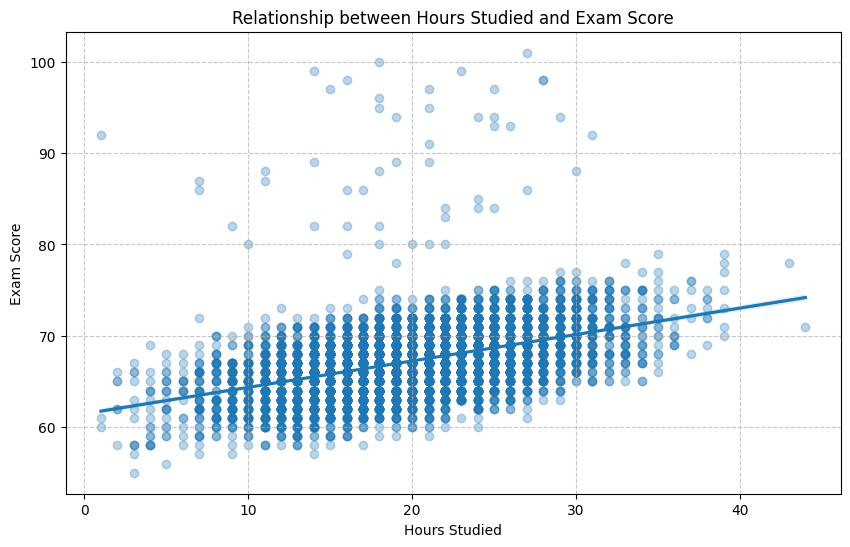

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.regplot(x='Hours_Studied', y='Exam_Score', data=df, scatter_kws={'alpha':0.3})
plt.title('Relationship between Hours Studied and Exam Score')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

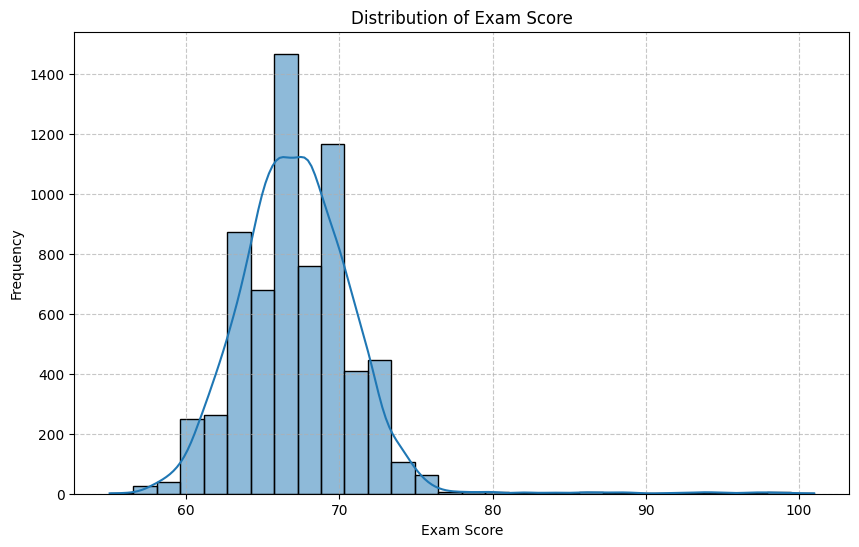

In [19]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Exam_Score'], kde=True, bins=30)
plt.title('Distribution of Exam Score')
plt.xlabel('Exam Score')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [20]:
import pandas as pd

# Get feature names from X (DataFrame before splitting)
feature_names = X.columns

# Get the coefficients from the trained model
coefficients = model.coef_

# Create a DataFrame to store feature importance
feature_importance = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})

# Sort features by the absolute value of their coefficients
feature_importance['Absolute_Coefficient'] = abs(feature_importance['Coefficient'])
feature_importance = feature_importance.sort_values(by='Absolute_Coefficient', ascending=False)

print("\nFeature Importance (sorted by absolute coefficient value):")
display(feature_importance.drop(columns='Absolute_Coefficient'))


Feature Importance (sorted by absolute coefficient value):


,Feature,Coefficient
8,Internet_Access,0.967763
15,Learning_Disabilities,-0.874608
4,Extracurricular_Activities,0.569081
13,Peer_Influence,0.532565
9,Tutoring_Sessions,0.502380
17,Distance_from_Home,0.467132
2,Parental_Involvement,-0.446969
3,Access_to_Resources,-0.404436
0,Hours_Studied,0.288626
11,Teacher_Quality,-0.237587


The table above shows the importance of each feature in predicting 'Exam_Score' based on the absolute value of their coefficients in the linear regression model. A higher absolute coefficient value indicates a stronger impact (positive or negative) of that feature on the 'Exam_Score'.

Visualizing the impact of the top 3 features: Internet_Access, Learning_Disabilities, Extracurricular_Activities


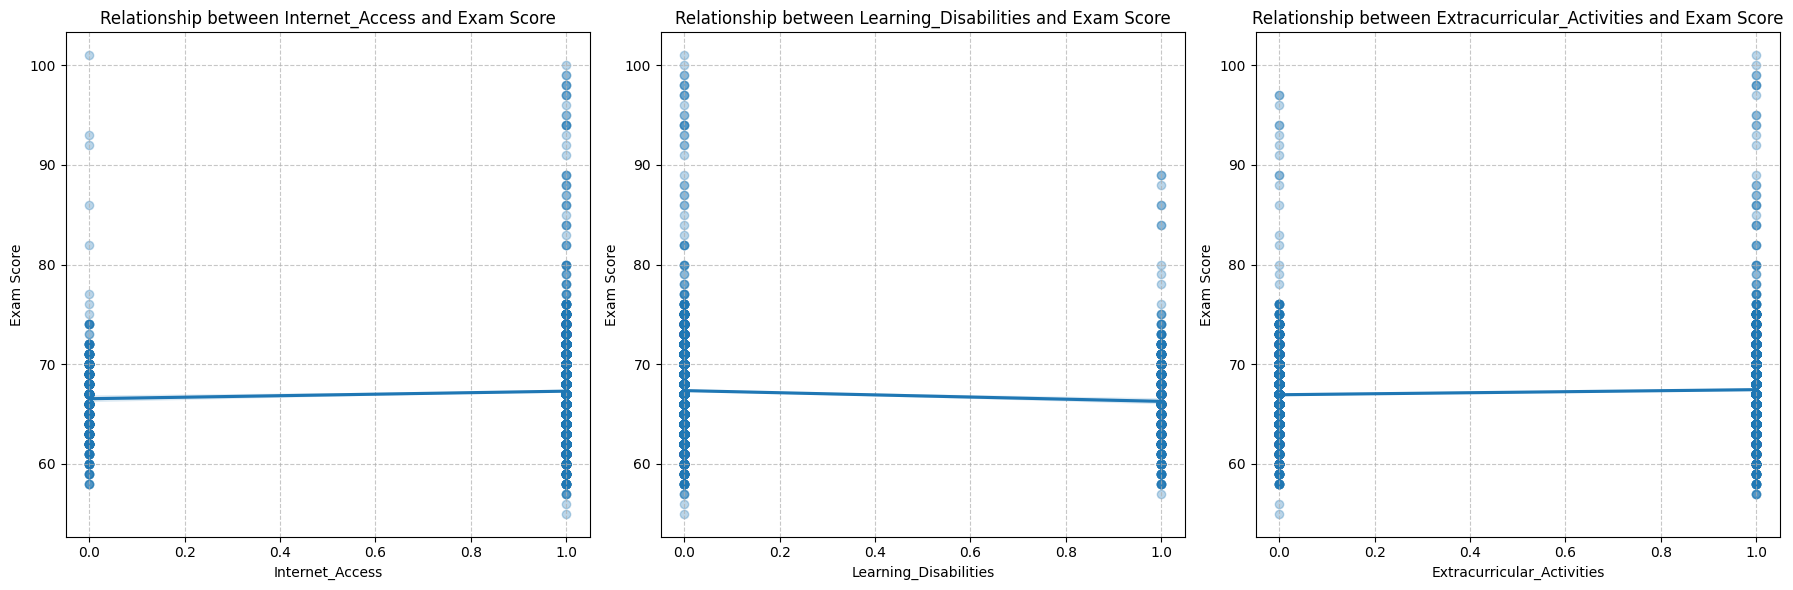

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the top 3 features from the feature_importance DataFrame
top_3_features = feature_importance.head(3)['Feature'].tolist()

print(f"Visualizing the impact of the top 3 features: {', '.join(top_3_features)}")

# Create subplots for each of the top 3 features
plt.figure(figsize=(18, 6))

for i, feature in enumerate(top_3_features):
    plt.subplot(1, 3, i + 1) # 1 row, 3 columns, i+1-th plot
    sns.regplot(x=feature, y='Exam_Score', data=df, scatter_kws={'alpha':0.3})
    plt.title(f'Relationship between {feature} and Exam Score')
    plt.xlabel(feature)
    plt.ylabel('Exam Score')
    plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

These plots illustrate the linear relationship between the top 3 most important features and the 'Exam_Score'. The regression line helps to visualize the trend identified by the model for each feature.

### Training a RandomForestRegressor Model

In [22]:
from sklearn.ensemble import RandomForestRegressor

# Initialize the RandomForestRegressor model
rf_model = RandomForestRegressor(random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

print("RandomForestRegressor model trained successfully.")

RandomForestRegressor model trained successfully.


In [23]:
# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

print("Predictions made on the test set using RandomForestRegressor.")

Predictions made on the test set using RandomForestRegressor.


In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Evaluate the RandomForestRegressor model
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Mean Absolute Error (MAE) for RandomForest: {mae_rf:.2f}")
print(f"Mean Squared Error (MSE) for RandomForest: {mse_rf:.2f}")
print(f"Root Mean Squared Error (RMSE) for RandomForest: {rmse_rf:.2f}")
print(f"R-squared (R2) for RandomForest: {r2_rf:.2f}")

Mean Absolute Error (MAE) for RandomForest: 1.13
Mean Squared Error (MSE) for RandomForest: 4.88
Root Mean Squared Error (RMSE) for RandomForest: 2.21
R-squared (R2) for RandomForest: 0.65


### Hyperparameter Tuning for RandomForestRegressor using GridSearchCV

In [25]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for RandomForestRegressor
param_grid = {
    'n_estimators': [100, 200, 300],  # Number of trees in the forest
    'max_depth': [None, 10, 20],      # Maximum depth of the tree
    'min_samples_split': [2, 5, 10],  # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 4]     # Minimum number of samples required to be at a leaf node
}

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42), # Use a fixed random_state for reproducibility
    param_grid=param_grid,
    cv=3,                                             # 3-fold cross-validation
    n_jobs=-1,                                        # Use all available CPU cores
    scoring='r2',                                     # Optimize for R-squared
    verbose=2                                         # Display progress
)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

print("Grid search completed.")
print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best R-squared score: {grid_search.best_score_:.2f}")

Fitting 3 folds for each of 81 candidates, totalling 243 fits
Grid search completed.
Best parameters found: {'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 300}
Best R-squared score: 0.63


In [26]:
# Get the best RandomForestRegressor model from grid search
best_rf_model = grid_search.best_estimator_

# Make predictions with the best model
y_pred_rf_tuned = best_rf_model.predict(X_test)

# Evaluate the tuned RandomForestRegressor model
mae_rf_tuned = mean_absolute_error(y_test, y_pred_rf_tuned)
mse_rf_tuned = mean_squared_error(y_test, y_pred_rf_tuned)
rmse_rf_tuned = np.sqrt(mse_rf_tuned)
r2_rf_tuned = r2_score(y_test, y_pred_rf_tuned)

print("\nPerformance of the tuned RandomForestRegressor model:")
print(f"Mean Absolute Error (MAE) for Tuned RandomForest: {mae_rf_tuned:.2f}")
print(f"Mean Squared Error (MSE) for Tuned RandomForest: {mse_rf_tuned:.2f}")
print(f"Root Mean Squared Error (RMSE) for Tuned RandomForest: {rmse_rf_tuned:.2f}")
print(f"R-squared (R2) for Tuned RandomForest: {r2_rf_tuned:.2f}")


Performance of the tuned RandomForestRegressor model:
Mean Absolute Error (MAE) for Tuned RandomForest: 1.09
Mean Squared Error (MSE) for Tuned RandomForest: 4.54
Root Mean Squared Error (RMSE) for Tuned RandomForest: 2.13
R-squared (R2) for Tuned RandomForest: 0.68


### Cross-Validation Comparison

In [27]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import numpy as np

# Initialize the models (ensure random_state for reproducibility where applicable)
linear_model_cv = LinearRegression()
# Use the best_rf_model obtained from GridSearchCV for comparison
rf_model_cv = best_rf_model

# Perform 5-fold cross-validation for Linear Regression
# Using the entire dataset (X, y) for cross-validation
cv_scores_lr = cross_val_score(linear_model_cv, X, y, cv=5, scoring='r2', n_jobs=-1)

print("\nLinear Regression Cross-Validation R-squared scores:", cv_scores_lr)
print(f"Mean R-squared (Linear Regression): {np.mean(cv_scores_lr):.2f} (Std: {np.std(cv_scores_lr):.2f})")

# Perform 5-fold cross-validation for Tuned RandomForestRegressor
cv_scores_rf = cross_val_score(rf_model_cv, X, y, cv=5, scoring='r2', n_jobs=-1)

print("\nRandomForestRegressor (Tuned) Cross-Validation R-squared scores:", cv_scores_rf)
print(f"Mean R-squared (RandomForestRegressor Tuned): {np.mean(cv_scores_rf):.2f} (Std: {np.std(cv_scores_rf):.2f})")


Linear Regression Cross-Validation R-squared scores: [0.55747493 0.64721503 0.63465934 0.65097326 0.7620576 ]
Mean R-squared (Linear Regression): 0.65 (Std: 0.07)

RandomForestRegressor (Tuned) Cross-Validation R-squared scores: [0.55156633 0.64665325 0.62238066 0.6546583  0.73129597]
Mean R-squared (RandomForestRegressor Tuned): 0.64 (Std: 0.06)


The cross-validation results provide a more reliable estimate of how well each model generalizes to unseen data. By comparing the mean R-squared scores and their standard deviations, we can better understand the consistency and performance of both models.

In [35]:
num_students = df.shape[0]
print(f"There are {num_students} students in this dataset.")

There are 6607 students in this dataset.


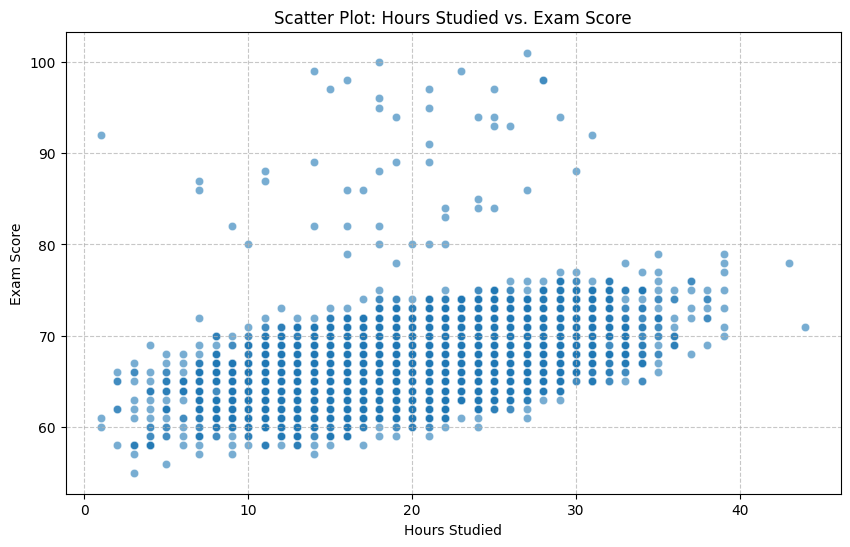

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Hours_Studied', y='Exam_Score', data=df, alpha=0.6)
plt.title('Scatter Plot: Hours Studied vs. Exam Score')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

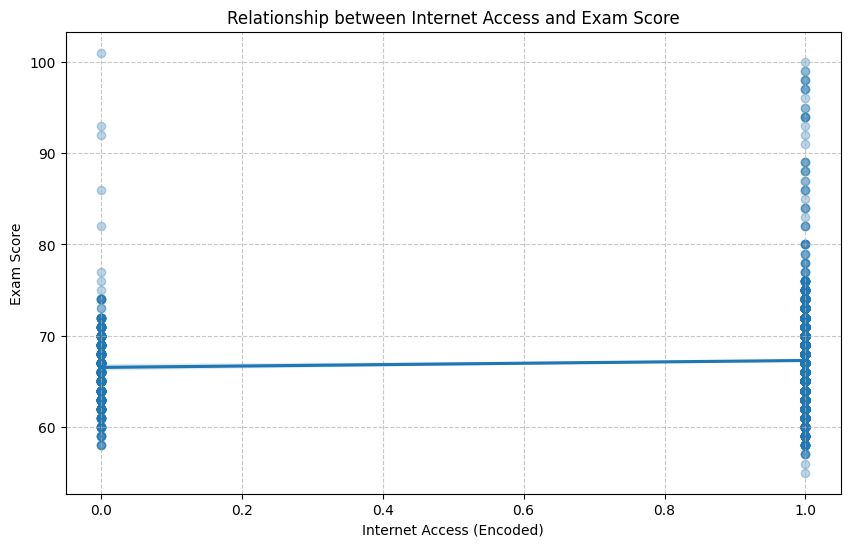

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.regplot(x='Internet_Access', y='Exam_Score', data=df, scatter_kws={'alpha':0.3})
plt.title('Relationship between Internet Access and Exam Score')
plt.xlabel('Internet Access (Encoded)')
plt.ylabel('Exam Score')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [32]:
import pandas as pd

# Ensure feature_importance is sorted by Absolute_Coefficient if not already
feature_importance = feature_importance.sort_values(by='Absolute_Coefficient', ascending=False)

print("Features with the strongest impact on 'Exam_Score' (ranked by absolute coefficient):")
display(feature_importance[['Feature', 'Coefficient']])

Features with the strongest impact on 'Exam_Score' (ranked by absolute coefficient):


,Feature,Coefficient
8,Internet_Access,0.967763
15,Learning_Disabilities,-0.874608
4,Extracurricular_Activities,0.569081
13,Peer_Influence,0.532565
9,Tutoring_Sessions,0.502380
17,Distance_from_Home,0.467132
2,Parental_Involvement,-0.446969
3,Access_to_Resources,-0.404436
0,Hours_Studied,0.288626
11,Teacher_Quality,-0.237587


Correlation between Parental_Involvement and Exam_Score: -0.09


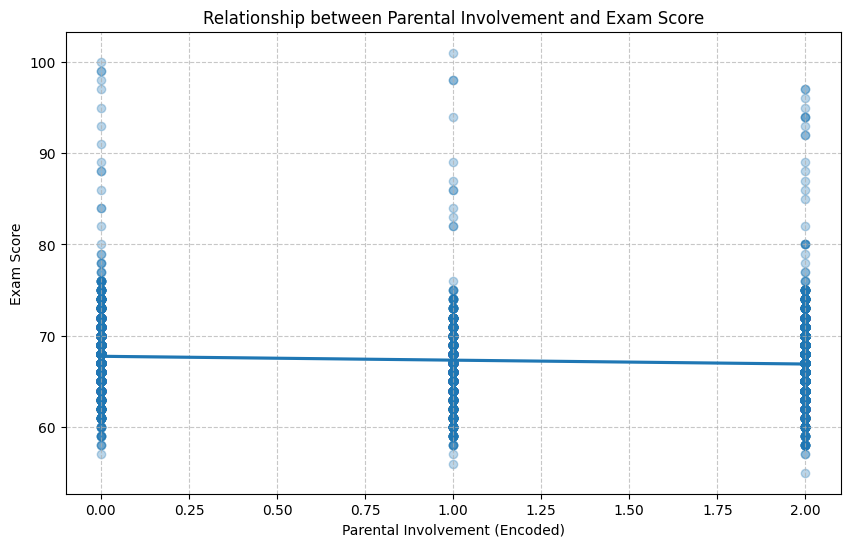

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation between 'Parental_Involvement' and 'Exam_Score'
correlation = df['Parental_Involvement'].corr(df['Exam_Score'])

print(f"Correlation between Parental_Involvement and Exam_Score: {correlation:.2f}")

# Visualize the relationship with a scatter plot and regression line
plt.figure(figsize=(10, 6))
sns.regplot(x='Parental_Involvement', y='Exam_Score', data=df, scatter_kws={'alpha':0.3})
plt.title('Relationship between Parental Involvement and Exam Score')
plt.xlabel('Parental Involvement (Encoded)')
plt.ylabel('Exam Score')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


### Interpretation of Correlation and Plot

*   **Correlation Coefficient:**
    *   A correlation coefficient ranges from -1 to 1.
    *   A value close to 1 indicates a strong positive linear relationship.
    *   A value close to -1 indicates a strong negative linear relationship.
    *   A value close to 0 indicates a weak or no linear relationship.

*   **Scatter Plot with Regression Line:**
    *   The scatter plot visualizes individual data points.
    *   The regression line (blue line) shows the general trend between the two variables.
    *   The shaded area around the regression line represents the confidence interval of the regression estimate.

By examining both the numerical correlation coefficient and the visual representation, we can determine the strength and direction of the linear relationship between parental involvement and exam scores. Remember that correlation does not imply causation.

### Final Model Performance Evaluation on Test Set

In [30]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("--- Linear Regression Model Performance ---")
# Predictions already exist as y_pred
mae_lr = mean_absolute_error(y_test, y_pred)
mse_lr = mean_squared_error(y_test, y_pred)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae_lr:.2f}")
print(f"Mean Squared Error (MSE): {mse_lr:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_lr:.2f}")
print(f"R-squared (R2): {r2_lr:.2f}")

print("\n--- Tuned RandomForestRegressor Model Performance ---")
# Predictions already exist as y_pred_rf_tuned
mae_rf_tuned_final = mean_absolute_error(y_test, y_pred_rf_tuned)
mse_rf_tuned_final = mean_squared_error(y_test, y_pred_rf_tuned)
rmse_rf_tuned_final = np.sqrt(mse_rf_tuned_final)
r2_rf_tuned_final = r2_score(y_test, y_pred_rf_tuned)

print(f"Mean Absolute Error (MAE): {mae_rf_tuned_final:.2f}")
print(f"Mean Squared Error (MSE): {mse_rf_tuned_final:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_rf_tuned_final:.2f}")
print(f"R-squared (R2): {r2_rf_tuned_final:.2f}")


--- Linear Regression Model Performance ---
Mean Absolute Error (MAE): 1.02
Mean Squared Error (MSE): 4.40
Root Mean Squared Error (RMSE): 2.10
R-squared (R2): 0.69

--- Tuned RandomForestRegressor Model Performance ---
Mean Absolute Error (MAE): 1.09
Mean Squared Error (MSE): 4.54
Root Mean Squared Error (RMSE): 2.13
R-squared (R2): 0.68


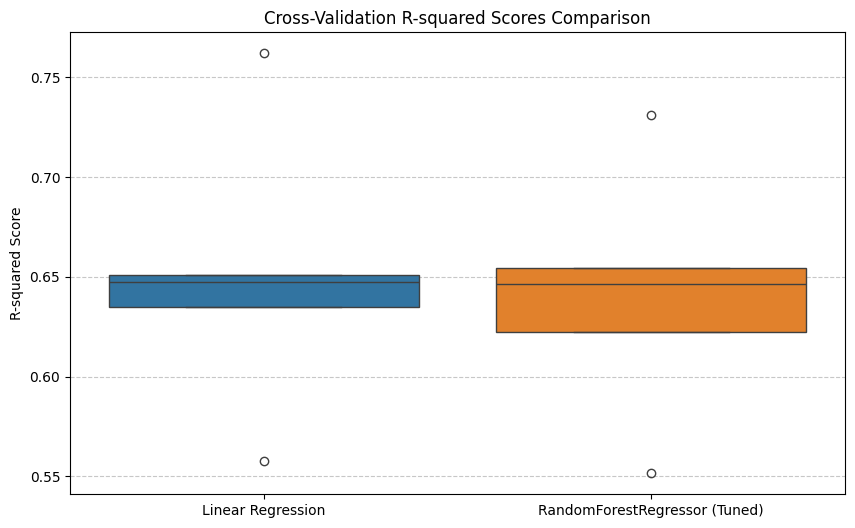

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Combine the cross-validation scores into a DataFrame for easy plotting
cv_results = pd.DataFrame({
    'Linear Regression': cv_scores_lr,
    'RandomForestRegressor (Tuned)': cv_scores_rf
})

plt.figure(figsize=(10, 6))
sns.boxplot(data=cv_results)
plt.title('Cross-Validation R-squared Scores Comparison')
plt.ylabel('R-squared Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


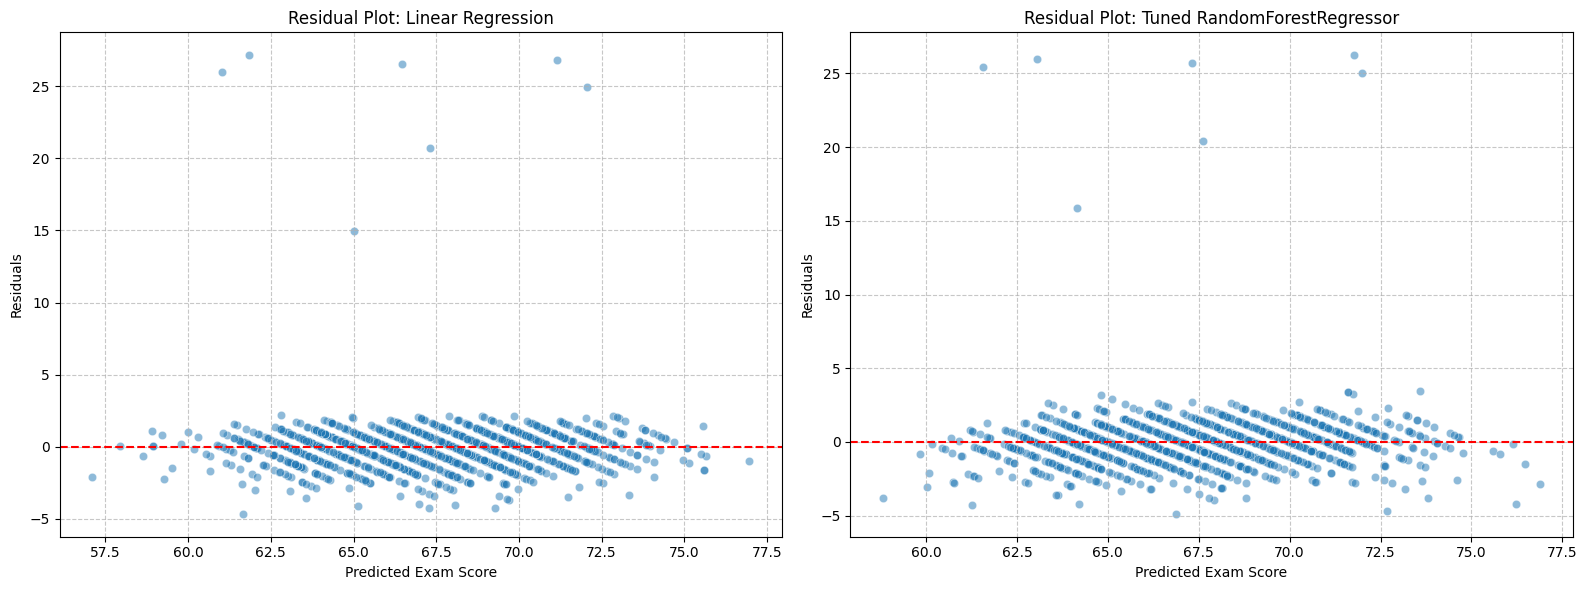

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate residuals for Linear Regression
residuals_lr = y_test - y_pred

# Calculate residuals for Tuned RandomForestRegressor
residuals_rf_tuned = y_test - y_pred_rf_tuned

# Create a figure with two subplots
plt.figure(figsize=(16, 6))

# Subplot 1: Residual Plot for Linear Regression
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_pred, y=residuals_lr, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residual Plot: Linear Regression')
plt.xlabel('Predicted Exam Score')
plt.ylabel('Residuals')
plt.grid(True, linestyle='--', alpha=0.7)

# Subplot 2: Residual Plot for Tuned RandomForestRegressor
plt.subplot(1, 2, 2)
sns.scatterplot(x=y_pred_rf_tuned, y=residuals_rf_tuned, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residual Plot: Tuned RandomForestRegressor')
plt.xlabel('Predicted Exam Score')
plt.ylabel('Residuals')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


### Interpretation of Residual Plots

*   **Ideal Scenario:** In an ideal scenario, the residual plot should show a random scatter of points around the horizontal line at zero. This indicates that the model is capturing the underlying patterns in the data well, and the errors are randomly distributed (homoscedasticity).

*   **Patterns to look for (and their implications):**
    *   **Funnel Shape (Heteroscedasticity):** If the spread of residuals increases or decreases as the predicted values increase, it suggests that the model's errors are not constant across the range of predictions. This violates the assumption of homoscedasticity.
    *   **Curvature/Non-linear Pattern:** If residuals show a discernible curve, it suggests that the model is missing a non-linear relationship between the features and the target variable. A more complex model or feature engineering might be needed.
    *   **Clusters:** Any obvious clusters of residuals could indicate problems with uncaptured categorical variables or other systematic errors.

By examining these plots, we can gain insights into the strengths and weaknesses of each model's predictive performance and whether any assumptions are violated.